<a href="https://colab.research.google.com/github/SotaYoshida/Lecture_DataScience/blob/master/Kadai_Z.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#課題Z

提出方法はJupyterNotebookに課題に相当する部分を付け足して提出しても良いし、
保存した図をワードか何かに貼り付けて整形しても良い.



#####日本地図を描くライブラリ japanmapを使う
(参考リンク https://takemaru-hirai.github.io/japan-map/)

In [2]:
!pip install japanmap
from japanmap import pref_names,pref_code,groups,picture
import matplotlib.pyplot as plt
from pylab import rcParams

     |████████████████████████████████| 174kB 4.5MB/s 
  Created wheel for japanmap: filename=japanmap-0.0.21-cp36-none-any.whl size=166793 sha256=22898337d4ae9aa48b5daf984b033bb00ee373372eaa03cfbe8ff234ceabb86d
  Stored in directory: /root/.cache/pip/wheels/a0/7b/2b/331437760ae95113fa973e5ad7af111588ce9c7e76feb14f56
Successfully built japanmap


pref_namesは県名のリスト

In [3]:
print(pref_names) #0番目は空で1から47に都道府県

['_', '北海道', '青森県', '岩手県', '宮城県', '秋田県', '山形県', '福島県', '茨城県', '栃木県', '群馬県', '埼玉県', '千葉県', '東京都', '神奈川県', '新潟県', '富山県', '石川県', '福井県', '山梨県', '長野県', '岐阜県', '静岡県', '愛知県', '三重県', '滋賀県', '京都府', '大阪府', '兵庫県', '奈良県', '和歌山県', '鳥取県', '島根県', '岡山県', '広島県', '山口県', '徳島県', '香川県', '愛媛県', '高知県', '福岡県', '佐賀県', '長崎県', '熊本県', '大分県', '宮崎県', '鹿児島県', '沖縄県']


pref_codeの引数に都道府県を入れると、上のリストのインデックス(JIS X0401準拠の都道府県コード)がわかります

In [4]:
print( pref_code("栃木県"))

9


groups関数は各ブロックに所属する県別コードの情報をもった辞書型

In [5]:
groups

{'中国': [31, 32, 33, 34, 35],
 '中部': [15, 16, 17, 18, 19, 20, 21, 22, 23],
 '九州': [40, 41, 42, 43, 44, 45, 46, 47],
 '北海道': [1],
 '四国': [36, 37, 38, 39],
 '東北': [2, 3, 4, 5, 6, 7],
 '近畿': [24, 25, 26, 27, 28, 29, 30],
 '関東': [8, 9, 10, 11, 12, 13, 14]}

コロン:の前にあるキーで要素を取得できます

In [6]:
groups["近畿"]

[24, 25, 26, 27, 28, 29, 30]

近畿に所属する県を表示してみます

In [7]:
tmp = groups["近畿"]
for i in tmp:
    print(pref_names[i])

三重県
滋賀県
京都府
大阪府
兵庫県
奈良県
和歌山県


私の大学時代の同級生が「三重県は近畿」だと主張していたのが
正しいとわかりました。

japanmapには、地図を描く関数もあります。

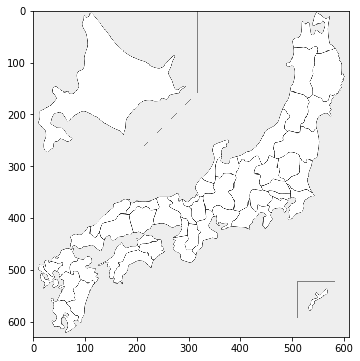

In [8]:
plt.figure(figsize=(6,6))
plt.imshow(picture())

matplotlibの章で習った、plt.show()ではなくplt.imshow() (画像を表示するときに使う関数)なのは、
japanmap内のpicture関数で呼び出された日本地図の画像を表示するからです。

栃木県を色で塗ってみましょう

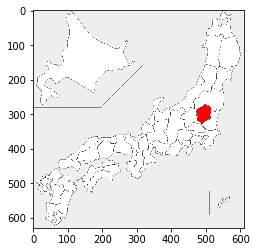

In [9]:
plt.imshow(picture({'栃木県': 'red'}))

画像を保存したいので、またドライブをマウントしておきましょう。

In [10]:
from google.colab import drive  
drive.mount('./gdrive')  

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at ./gdrive


In [11]:
plt.savefig('./gdrive/My Drive/Colab_pic/Tochigi.png',dpi=500) ##マイドライブのColab_pic内に保存

<Figure size 432x288 with 0 Axes>

###ヒートマップの作成


何らかの値の大小に応じて、日本地図を塗り分けてみましょう

In [12]:
import numpy as np
np.random.seed(12) ##結果が毎回同じになるよう乱数の種を固定
data = [ 30 + 10 * np.random.normal() * np.random.uniform() for i  in range(47) ] ## 都道府県の数だけ適当なランダムデータを作成
data = [ None ] + data  ### pref_namesと形を合わせたリストにしておきましょう。１番目はNone
data[13]=500
print(len(data)) 

48
48


ヒートマップを作ってみましょう。

(2月14日時点で、以下のコードにミスがあったのですが、工学部の高信さんの質問で解消しました。ありがとうございます)

d {1: (103, 37, 254), 2: (109, 28, 254), 3: (97, 46, 253), 4: (119, 12, 254), 5: (105, 34, 254), 6: (105, 34, 254), 7: (109, 28, 254), 8: (105, 34, 254), 9: (99, 43, 254), 10: (115, 18, 254), 11: (97, 46, 253), 12: (109, 28, 254), 13: (255, 0, 0), 14: (103, 37, 254), 15: (109, 28, 254), 16: (127, 0, 255), 17: (113, 21, 254), 18: (113, 21, 254), 19: (105, 34, 254), 20: (105, 34, 254), 21: (105, 34, 254), 22: (105, 34, 254), 23: (105, 34, 254), 24: (105, 34, 254), 25: (103, 37, 254), 26: (105, 34, 254), 27: (105, 34, 254), 28: (95, 49, 253), 29: (103, 37, 254), 30: (101, 40, 254), 31: (103, 37, 254), 32: (105, 34, 254), 33: (105, 34, 254), 34: (111, 25, 254), 35: (95, 49, 253), 36: (103, 37, 254), 37: (101, 40, 254), 38: (105, 34, 254), 39: (117, 15, 254), 40: (109, 28, 254), 41: (97, 46, 253), 42: (115, 18, 254), 43: (109, 28, 254), 44: (107, 31, 254), 45: (107, 31, 254), 46: (107, 31, 254), 47: (105, 34, 254)}


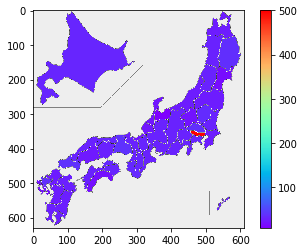

In [15]:
cmap = plt.get_cmap('jet')   ##他にも 'coolwarm','CMRmap','RdBu', 'RdYlBu','Spectral','rainbow'などがよく使われます
#cmap = plt.get_cmap('RdYlBu')  お好みで変えてみましょう
cmap = plt.get_cmap('rainbow')


norm = plt.Normalize(vmin=min(data[1:]), vmax=max(data[1:])) ## 0番目は意味無しデータなので除く
x = np.array(data[1:]) 
x = (x - min(x)) / (max(x) - min(x)) #最大1 最小0にデータを規格化

############# データに対する辞書オブジェクト {key:値} の作成
## 実数値のRGBを整数値にして返す関数 tintの定義(define)
def tint(t): 
    return tuple(int(_) for _ in t)
####関数 tint 終わり
d = {i+1: tint(cmap(x[i], bytes=True)[:3]) for i in range(47)} ## bytes=True は0-255で指定するかどうか
print("d",d) ## dの中身は {key(都道府県コード):値(RGBの値)}
plt.colorbar(plt.cm.ScalarMappable(norm, cmap)) ## 図にカラーバーをplot
#############
plt.imshow(picture(d))

ヒント: 上のdataに相当するところに、興味のある量を突っ込めば上のコードが流用できるかも。